# Bibliotekos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from scipy import stats

from sklearn.inspection import permutation_importance
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Duomenys

In [2]:
data = pd.read_csv("../datasets_prep/dm_project_dataset.csv")
data['observationTime'] = pd.to_datetime(data['observationTime'])
data.columns

Index(['observationTime', 'absorbing_aerosol_index',
       'NO2_column_number_density', 'stratospheric_NO2_column_number_density',
       'NO2_slant_column_number_density', 'tropopause_pressure',
       'H2O_column_number_density', 'BrO', 'BrO_Error', 'NO2', 'NO2_Error',
       'O3', 'O3_Error', 'pm10', 'pm2p5', 'sia', 'nmvoc', 'dust', 'nh3',
       'pans', 'tp', 't2m', 'airTemperature', 'seaLevelPressure',
       'relativeHumidity', 'missforest_precipitation', 'xgb_cloudCover',
       'feelsLikeTemperature_fixed', 'windSpeed_fixed', 'windGust_fixed',
       'windDirection_fixed'],
      dtype='object')

In [3]:
# data = data.drop(columns=['BrO_Error', 'NO2_Error', 'O3_Error', 't2m'])
data = data.drop(columns=['absorbing_aerosol_index', 'NO2_column_number_density', 'stratospheric_NO2_column_number_density',
                          'NO2_slant_column_number_density', 'tropopause_pressure', 'H2O_column_number_density',
                          'BrO', 'BrO_Error', 'NO2', 'NO2_Error', 'O3', 'O3_Error', 'pm10', 'pm2p5', 'sia', 'nmvoc',
                          'dust', 'nh3', 'pans', 't2m',])
data['month'] = data['observationTime'].dt.month
data['day_of_year'] = data['observationTime'].dt.dayofyear
data['day_of_week'] = data['observationTime'].dt.dayofweek

In [4]:
data.columns

Index(['observationTime', 'tp', 'airTemperature', 'seaLevelPressure',
       'relativeHumidity', 'missforest_precipitation', 'xgb_cloudCover',
       'feelsLikeTemperature_fixed', 'windSpeed_fixed', 'windGust_fixed',
       'windDirection_fixed', 'month', 'day_of_year', 'day_of_week'],
      dtype='object')

In [5]:
data.head(5)

,observationTime,tp,airTemperature,seaLevelPressure,relativeHumidity,missforest_precipitation,xgb_cloudCover,feelsLikeTemperature_fixed,windSpeed_fixed,windGust_fixed,windDirection_fixed,month,day_of_year,day_of_week
0,2018-07-01,14.653358,11.295833,1010.637500,72.791667,9.1,89.375000,10.933333,3.762500,13.9,356.0,7,182,6
1,2018-07-02,6.475957,10.866667,1006.662500,94.000000,11.9,91.500000,10.429167,2.516667,7.0,327.0,7,183,0
2,2018-07-03,9.607317,13.387500,1008.454167,90.041667,10.0,89.375000,13.387500,2.537500,8.3,271.0,7,184,1
3,2018-07-04,0.013308,13.591667,1009.237500,88.291667,13.9,88.333333,13.591667,2.358333,8.7,288.0,7,185,2
4,2018-07-05,0.000000,16.291667,1008.079167,70.208333,0.0,66.000000,16.291667,1.283333,6.1,293.0,7,186,3


# Random Forest realizacija

## Požymių sukūrimas

### Vėlavimai

In [6]:
def lags_fun(column_name, lag_value, data):
    
    new_col_name = f"{column_name}_lag-{lag_value}"
    data.loc[:, new_col_name] = data[column_name].shift(lag_value)

In [7]:
lags_info = {
    # # METEO
    # 'airTemperature': [1, 3, 9, 10],
    'airTemperature': [9, 10],
    # 'seaLevelPressure': [1, 2],
    # 'relativeHumidity': [1, 2],
    # 'xgb_cloudCover': [1, 2],
    'xgb_cloudCover': [1],
    # 'windSpeed_fixed': [1, 2, 3],
    'windSpeed_fixed': [1],
    # 'windGust_fixed': [1, 2],
    # 'windDirection_fixed': [4, 10]
}

for col, lags in lags_info.items():
    if isinstance(lags, list):
        for lag in lags:
            lags_fun(col, lag, data)
    else:
        lags_fun(col, lags, data)

In [8]:
data['target_precipitation'] = data['missforest_precipitation'].shift(-1)

### Rolling window

In [9]:
def rolling_window_fun(column_name, window_value, data):

    new_col_name = f"{column_name}_window-{window_value}"
    # data.loc[:, new_col_name] = data[column_name].rolling(window=window_value).mean().shift(1)
    data.loc[:, new_col_name] = data[column_name].rolling(window=window_value).mean()

In [10]:
window_info = {
    # 'airTemperature': [4, 11],
    # 'seaLevelPressure': [3, 7],
    'seaLevelPressure': [7],
    # 'relativeHumidity': [3, 5],
    # 'xgb_cloudCover': [3, 5],
    # 'windSpeed_fixed': [4],
    # 'windGust_fixed': [3],
    'windDirection_fixed': [11]
}

for col, windows in window_info.items():
    if isinstance(windows, list):
        for window in windows:
            rolling_window_fun(col, window, data)
    else:
        rolling_window_fun(col, windows, data)

In [11]:
data_clean = data.dropna()

In [12]:
data_clean.columns

Index(['observationTime', 'tp', 'airTemperature', 'seaLevelPressure',
       'relativeHumidity', 'missforest_precipitation', 'xgb_cloudCover',
       'feelsLikeTemperature_fixed', 'windSpeed_fixed', 'windGust_fixed',
       'windDirection_fixed', 'month', 'day_of_year', 'day_of_week',
       'airTemperature_lag-9', 'airTemperature_lag-10', 'xgb_cloudCover_lag-1',
       'windSpeed_fixed_lag-1', 'target_precipitation',
       'seaLevelPressure_window-7', 'windDirection_fixed_window-11'],
      dtype='object')

## Požymių atrinkimas

### Požymiai atrinkti pagal algoritmo kintamųjų svarbą

In [13]:
# # Modelio atrinkti požymiai iš originalios aibės
models_selected_features = ['tp', 'xgb_cloudCover', 'day_of_year', 'missforest_precipitation', 'windGust_fixed',
                            'feelsLikeTemperature_fixed', 'month', 'day_of_week',
                            'airTemperature_lag-9', 'airTemperature_lag-10', 'xgb_cloudCover_lag-1', 'windSpeed_fixed_lag-1',
                            'seaLevelPressure_window-7', 'windDirection_fixed_window-11']

models_selected_features_lags_im = ['tp', 'airTemperature_lag-10', 'windDirection_fixed_window-11', 'windGust_fixed', 'xgb_cloudCover',
                                    'feelsLikeTemperature_fixed', 'seaLevelPressure_window-7', 'missforest_precipitation',
                                    'day_of_year', 'airTemperature_lag-9', 'month']

In [14]:
data_clean = data_clean[models_selected_features_lags_im + ['observationTime', 'target_precipitation']].copy()

### Aibių sudarymas

In [15]:
train_end = '2024-02-01'
val_end = '2025-02-01'

train = data_clean[data_clean['observationTime'] < train_end]
val = data_clean[(data_clean['observationTime'] >= train_end) & (data_clean['observationTime'] <= val_end)]
test  = data_clean[data_clean['observationTime'] > val_end]

print(f"Train: {train.shape}, nuo {train['observationTime'].min()} iki {train['observationTime'].max()}")
print(f"Val: {val.shape}, nuo {val['observationTime'].min()} iki {val['observationTime'].max()}")
print(f"Test:  {test.shape},  nuo {test['observationTime'].min()} iki {test['observationTime'].max()}")

Train: (2031, 13), nuo 2018-07-11 00:00:00 iki 2024-01-31 00:00:00
Val: (367, 13), nuo 2024-02-01 00:00:00 iki 2025-02-01 00:00:00
Test:  (363, 13),  nuo 2025-02-02 00:00:00 iki 2026-01-30 00:00:00


In [16]:
target = 'target_precipitation'
drop_cols = ['observationTime', target]

X_train = train.drop(columns=drop_cols)
y_train = train[target]

X_val = val.drop(columns=drop_cols)
y_val = val[target]

X_test = test.drop(columns=drop_cols)
y_test = test[target]

### Realizacija

In [17]:
X_train.columns

Index(['tp', 'airTemperature_lag-10', 'windDirection_fixed_window-11',
       'windGust_fixed', 'xgb_cloudCover', 'feelsLikeTemperature_fixed',
       'seaLevelPressure_window-7', 'missforest_precipitation', 'day_of_year',
       'airTemperature_lag-9', 'month'],
      dtype='object')

In [18]:
rf_default = RandomForestRegressor(random_state=123)
rf_default.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [19]:
rf_default_pred = rf_default.predict(X_val)

### Metrikos

In [20]:
def metrics_fun(y_val_true, rf_pred_val):
    print(f'R^2:  {r2_score(y_val_true, rf_pred_val)}')
    print(f'MAE:  {mean_absolute_error(y_val_true, rf_pred_val)}')
    print(f'RMSE: {np.sqrt(mean_squared_error(y_val_true, rf_pred_val))}')
    # print(f'MAPE: {mean_absolute_percentage_error(y_val_true, rf_pred_val)}')

    corr, p_value = stats.spearmanr(y_val_true, rf_pred_val)
    print(f"r_s:  {corr}")

Globalaus modelio paklaidos - validavimo aibė

In [21]:
metrics_fun(y_val, X_val['tp'])

R^2:  0.5026324749895323
MAE:  1.4685700168000633
RMSE: 3.40532484561435
r_s:  0.7378103776223065


RF modelio paklaidos

In [22]:
metrics_fun(y_val, rf_default_pred)

R^2:  0.5487152673734608
MAE:  1.4739925531954372
RMSE: 3.2437334180551343
r_s:  0.6937481219444944


In [23]:
len(rf_default_pred)

367

### Vizualizacija

In [ ]:
plot_df = val.loc[y_val.index, ['observationTime', 'target_precipitation', 'tp']].copy()
plot_df['prediction'] = rf_default_pred
plot_df = plot_df.sort_values('observationTime')

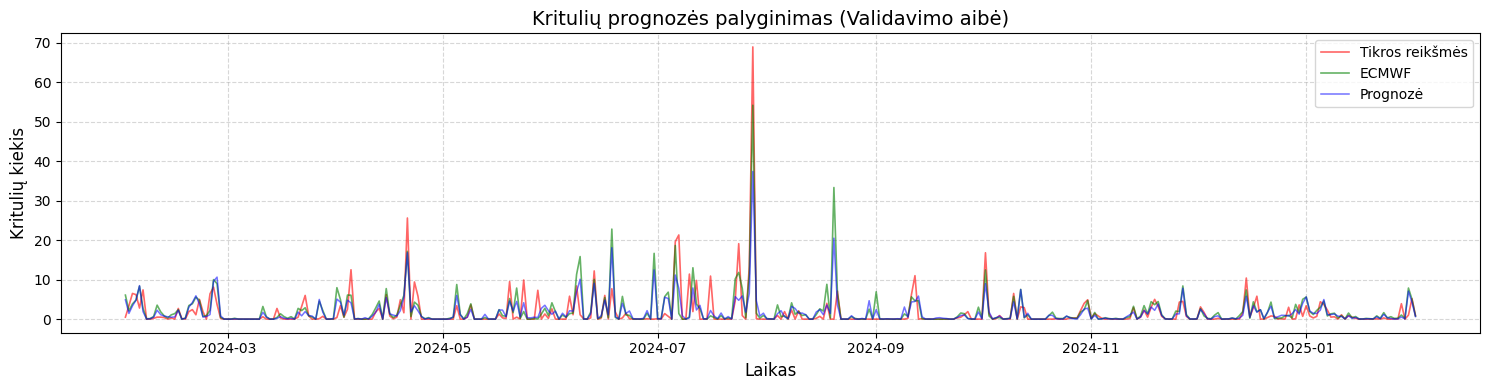

In [25]:
fig, ax1 = plt.subplots(figsize=(15, 4))
ax1.plot(plot_df['observationTime'], plot_df['target_precipitation'], label='Tikros reikšmės', color='red', linewidth=1.2, alpha=0.6)
ax1.plot(plot_df['observationTime'], plot_df['tp'], label='ECMWF', color='green', linewidth=1.2, alpha=0.6)
ax1.plot(plot_df['observationTime'], plot_df['prediction'], label='Prognozė', color='blue', linewidth=1.1, alpha=0.55)
ax1.legend(loc='upper right', fontsize=10, frameon=True)
ax1.set_title("Kritulių prognozės palyginimas (Validavimo aibė)", fontsize=14)
ax1.set_xlabel("Laikas", fontsize=12)
ax1.set_ylabel("Kritulių kiekis", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)

fig.tight_layout()
plt.show()

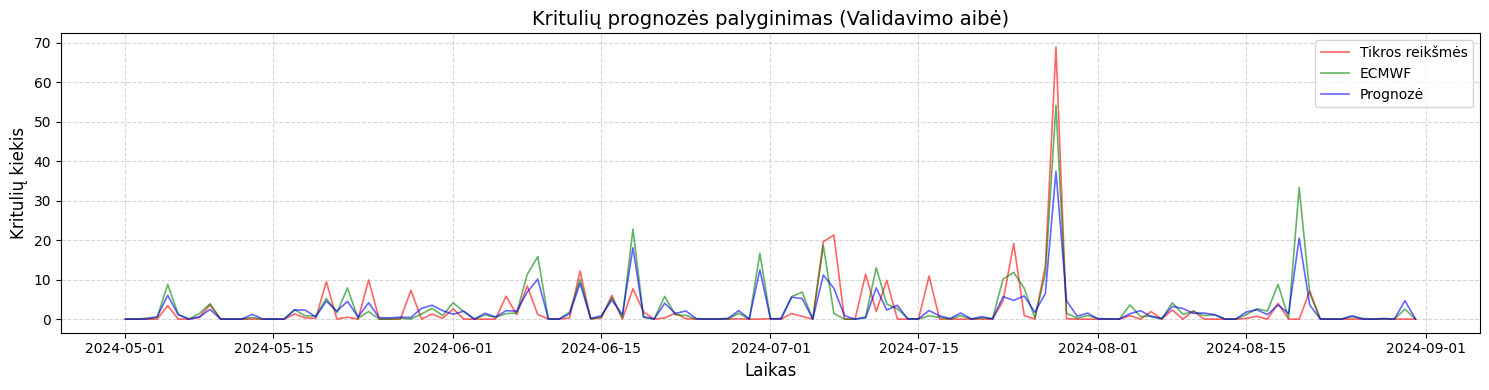

In [26]:
short_period = plot_df[(plot_df['observationTime'] >= '2024-05-01') & (plot_df['observationTime'] < '2024-09-01')]

fig, ax1 = plt.subplots(figsize=(15, 4))
ax1.plot(short_period['observationTime'], short_period['target_precipitation'], label='Tikros reikšmės', color='red', linewidth=1.2, alpha=0.6)
ax1.plot(short_period['observationTime'], short_period['tp'], label='ECMWF', color='green', linewidth=1.2, alpha=0.6)
ax1.plot(short_period['observationTime'], short_period['prediction'], label='Prognozė', color='blue', linewidth=1.2, alpha=0.6)
ax1.legend(loc='upper right', fontsize=10, frameon=True)
ax1.set_title("Kritulių prognozės palyginimas (Validavimo aibė)", fontsize=14)
ax1.set_xlabel("Laikas", fontsize=12)
ax1.set_ylabel("Kritulių kiekis", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)

fig.tight_layout()
plt.show()

### Požymių reikšmingumas

In [27]:
rf_default_importances = rf_default.feature_importances_
rf_default_importances

array([0.54773273, 0.06970922, 0.03832879, 0.04174935, 0.05848928,
       0.08970606, 0.04633301, 0.03356462, 0.02614519, 0.04110953,
       0.00713222])

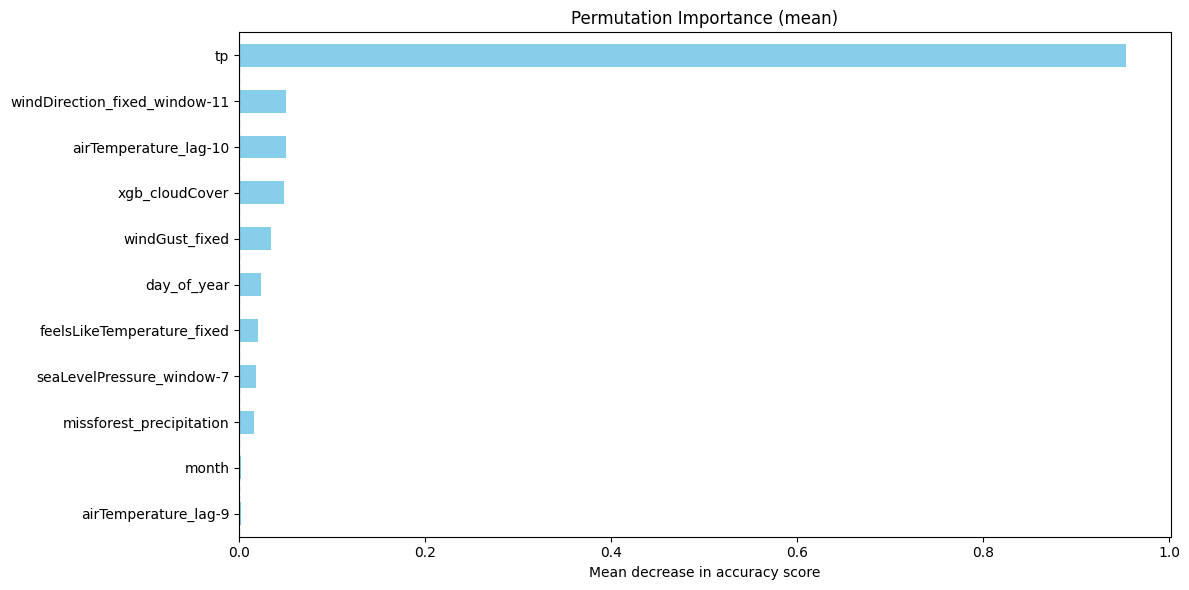

In [28]:
result = permutation_importance(rf_default, X_val, y_val, n_repeats=5, random_state=123)
sorted_importances_idx = result.importances_mean.argsort()
importances_df = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X_val.columns[sorted_importances_idx]
)

forest_importances = pd.Series(result.importances_mean, index=X_val.columns)
forest_importances = forest_importances[forest_importances > 0]
forest_importances = forest_importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
forest_importances.plot.barh(ax=ax, color='skyblue')
ax.set_title("Permutation Importance (mean)")
ax.set_xlabel("Mean decrease in accuracy score")
ax.axvline(x=0, color="k", linestyle="--")

fig.tight_layout()
plt.show()

In [29]:
forest_importances

airTemperature_lag-9             0.002370
month                            0.002683
missforest_precipitation         0.016009
seaLevelPressure_window-7        0.018405
feelsLikeTemperature_fixed       0.020035
day_of_year                      0.023369
windGust_fixed                   0.034950
xgb_cloudCover                   0.048835
airTemperature_lag-10            0.050281
windDirection_fixed_window-11    0.050802
tp                               0.953960
dtype: float64

## Optimalių hiperparametrų atrinkimas

### Hiperparametrų kitimas

In [30]:
from sklearn.model_selection import validation_curve
from sklearn.metrics import make_scorer

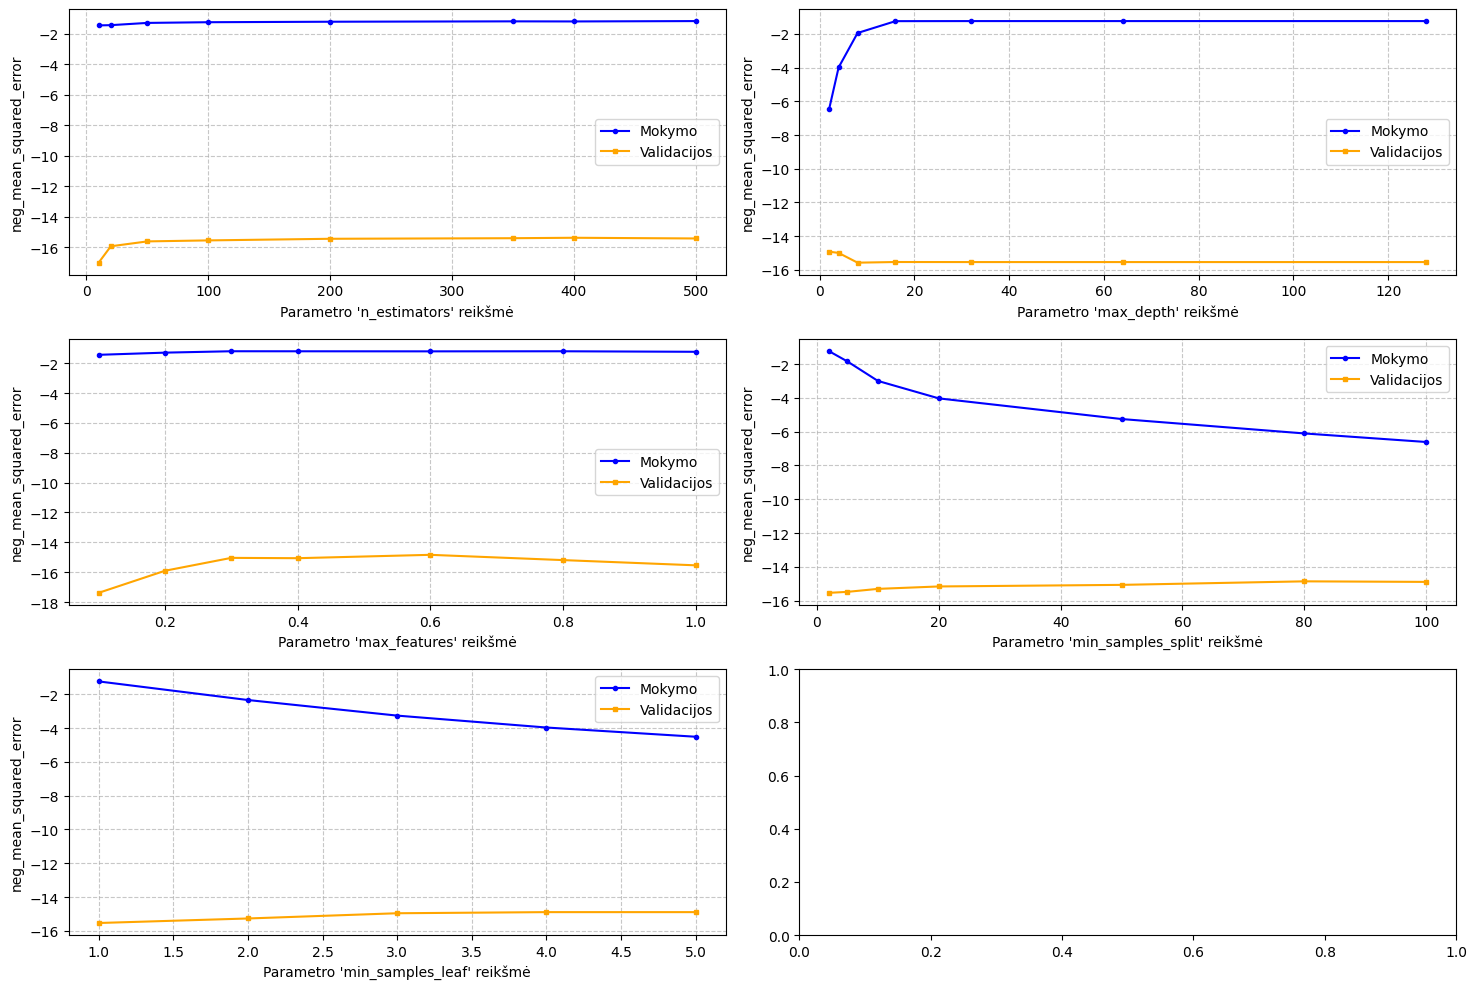

In [31]:
params = [
    {"name": "n_estimators", "range": [10, 20, 50, 100, 200, 350, 400, 500]},
    {"name": "max_depth", "range": [2, 4, 8, 16, 32, 64, 128]},
    {"name": "max_features", "range": [0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 1.0]},
    {"name": "min_samples_split", "range": [2, 5, 10, 20, 50, 80, 100]},
    {"name": "min_samples_leaf", "range": [1, 2, 3, 4, 5]}
]


fig, axes = plt.subplots(3, 2, figsize=(15, 10))
axes = axes.flatten()
tscv = TimeSeriesSplit(n_splits=5)

for i, p in enumerate(params):

    rf = RandomForestRegressor(random_state=123)
    
    train_scores, test_scores = validation_curve(
        rf, X_train, y_train, 
        param_name=p["name"], param_range=p["range"],
        cv=tscv, scoring="neg_mean_squared_error", n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    
    axes[i].plot(p["range"], train_mean, label="Mokymo", marker='o', color='blue', markersize=3)
    axes[i].plot(p["range"], test_mean, label="Validacijos", marker='s', color='orange', markersize=3)

    axes[i].set_xlabel(f"Parametro '{p['name']}' reikšmė")
    axes[i].set_ylabel("neg_mean_squared_error")
    axes[i].grid(True, linestyle='--', alpha=0.7)
    axes[i].legend()

plt.tight_layout()
plt.show()

In [ ]:
# def huber_loss_func(y_true, y_pred, delta=1.0):
#     error = y_true - y_pred
#     is_small_error = np.abs(error) <= delta
#     squared_loss = 0.5 * np.power(error, 2)
#     linear_loss = delta * (np.abs(error) - 0.5 * delta)
#     return np.where(is_small_error, squared_loss, linear_loss).mean()

# huber_scorer = make_scorer(huber_loss_func, greater_is_better=False, delta=1.0)

In [ ]:
param_grid = {
    'n_estimators':      [100, 150, 200, 250],
    'max_depth':         [8, 10, 12, 16],
    'max_features':      [0.25, 0.3, 0.4, 0.5, 0.6, 0.65],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 3],
}

tscv = TimeSeriesSplit(n_splits=5)

# 'neg_mean_absolute_error'
grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=123), param_grid=param_grid,
                             cv=tscv, scoring='neg_root_mean_squared_error')
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
print(f"Geriausi parametrai: {grid_search.best_params_}")

Geriausi parametrai: {'max_depth': 8, 'max_features': 0.6, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


In [33]:
best_GS_rf = RandomForestRegressor(max_depth=8, max_features=0.6, min_samples_leaf=2,
                                   min_samples_split=2, n_estimators=100, random_state=123)
best_GS_rf.fit(X_train, y_train)
best_pred = best_GS_rf.predict(X_val)
metrics_fun(y_val, best_pred)

R^2:  0.506031204047342
MAE:  1.4998749834287661
RMSE: 3.393669866216206
r_s:  0.7007373883124818


In [34]:
default_pred = rf_default.predict(X_val)
metrics_fun(y_val, default_pred)

R^2:  0.5487152673734608
MAE:  1.4739925531954372
RMSE: 3.2437334180551343
r_s:  0.6937481219444944


Modelis su numatytosiomis hiperparametrų reikšmėmis pasiekia geresnes metriku reikšmes validavimo aibėje

## Testavimo aibės rezultatai

### Metrikos

Globalaus

In [35]:
metrics_fun(y_test, X_test['tp'])

R^2:  0.49064675292448867
MAE:  1.4333678202939222
RMSE: 3.1415679902213944
r_s:  0.7629911314397974


RF

In [36]:
y_test_pred = rf_default.predict(X_test)
metrics_fun(y_test, y_test_pred)

R^2:  0.48389128417848837
MAE:  1.408705831672351
RMSE: 3.162332419221058
r_s:  0.718640503107994


### Vizualizacija

In [37]:
plot_test_df = test.loc[y_test.index, ['observationTime', 'target_precipitation', 'tp']].copy()
plot_test_df['prediction'] = y_test_pred
plot_test_df = plot_test_df.sort_values('observationTime')

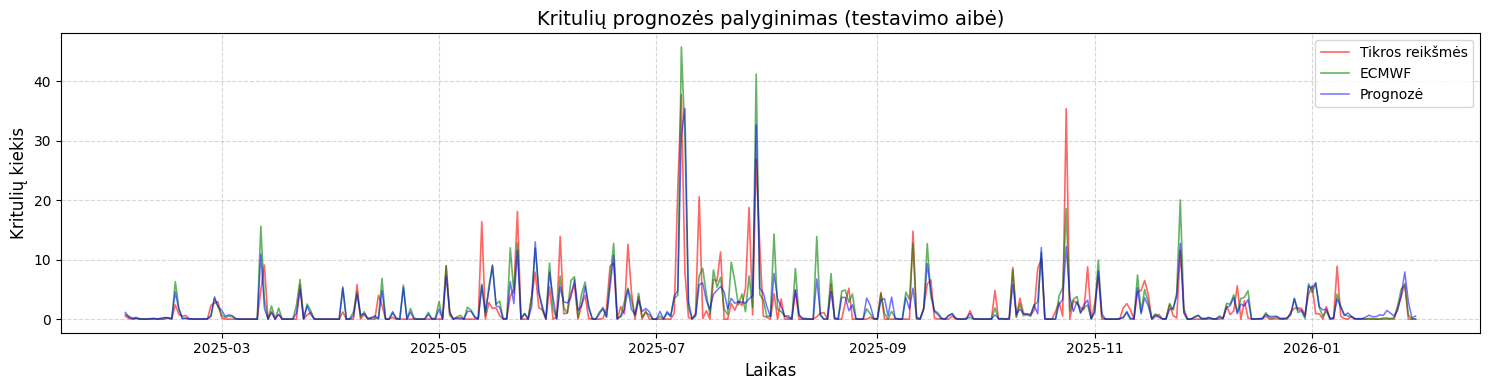

In [38]:
fig, ax1 = plt.subplots(figsize=(15, 4))
ax1.plot(plot_test_df['observationTime'], plot_test_df['target_precipitation'], label='Tikros reikšmės', color='red', linewidth=1.2, alpha=0.6)
ax1.plot(plot_test_df['observationTime'], plot_test_df['tp'], label='ECMWF', color='green', linewidth=1.2, alpha=0.6)
ax1.plot(plot_test_df['observationTime'], plot_test_df['prediction'], label='Prognozė', color='blue', linewidth=1.1, alpha=0.55)
ax1.legend(loc='upper right', fontsize=10, frameon=True)
ax1.set_title("Kritulių prognozės palyginimas (testavimo aibė)", fontsize=14)
ax1.set_xlabel("Laikas", fontsize=12)
ax1.set_ylabel("Kritulių kiekis", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)

fig.tight_layout()
plt.show()

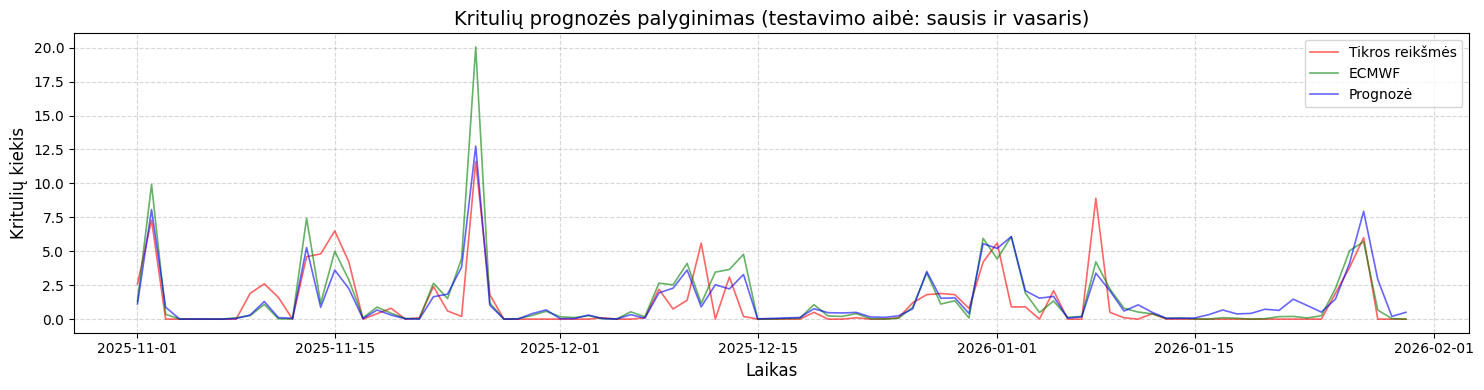

In [39]:
short_period = plot_test_df[(plot_test_df['observationTime'] >= '2025-11-01') & (plot_test_df['observationTime'] <= '2026-01-30')]
# nuo 2025-02-02 00:00:00 iki 2026-01-30 00:00:00
fig, ax1 = plt.subplots(figsize=(15, 4))
ax1.plot(short_period['observationTime'], short_period['target_precipitation'], label='Tikros reikšmės', color='red', linewidth=1.2, alpha=0.6)
ax1.plot(short_period['observationTime'], short_period['tp'], label='ECMWF', color='green', linewidth=1.2, alpha=0.6)
ax1.plot(short_period['observationTime'], short_period['prediction'], label='Prognozė', color='blue', linewidth=1.2, alpha=0.6)
ax1.legend(loc='upper right', fontsize=10, frameon=True)
ax1.set_title("Kritulių prognozės palyginimas (testavimo aibė: sausis ir vasaris)", fontsize=14)
ax1.set_xlabel("Laikas", fontsize=12)
ax1.set_ylabel("Kritulių kiekis", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)

fig.tight_layout()
plt.show()

### Prognozių įrašymas

In [40]:
prediction1 = pd.DataFrame(data = {'observationTime': val['observationTime'] + pd.Timedelta(days=1), 'rf_prediction': rf_default_pred, 'actual':val['target_precipitation'].values, 'ECMWF':val['tp'].values})
prediction2 = pd.DataFrame(data = {'observationTime': test['observationTime'] + pd.Timedelta(days=1), 'rf_prediction': y_test_pred, 'actual':test['target_precipitation'].values, 'ECMWF':test['tp'].values})
pd.concat([prediction1, prediction2]).to_csv('RF_prediction_without.csv', index=False)

---

In [41]:
rf_data_w = pd.read_csv("RF_prediction_without.csv")
rf_data_w['observationTime'] = pd.to_datetime(rf_data_w['observationTime'])
rf_data_w.head()

,observationTime,rf_prediction,actual,ECMWF
0,2024-02-02,4.872,0.5,6.074154
1,2024-02-03,1.437,3.4,2.074088
2,2024-02-04,3.334,6.5,3.847310
3,2024-02-05,4.810,6.2,4.799108
4,2024-02-06,8.485,2.8,8.335825


In [42]:
xgb_data_w = pd.read_csv("xgboost_pred_no_pollution.csv")
xgb_data_w['observationTime'] = pd.to_datetime(xgb_data_w['observationTime'])
xgb_data_w.head()

,observationTime,actual,xgb_predicted
0,2018-07-08,0.0,0.503422
1,2018-07-09,0.0,0.305401
2,2018-07-10,0.0,0.396395
3,2018-07-11,0.6,0.964347
4,2018-07-12,0.3,1.968365


In [43]:
ssa_lstm_data_w = pd.read_csv("SSA-LSTM_pred_less_features.csv")
ssa_lstm_data_w['observationTime'] = pd.to_datetime(ssa_lstm_data_w['observationTime'])
ssa_lstm_data_w.head()

,Unnamed: 0,observationTime,actual,SSA-LSTM
0,0,2024-08-11,2.1,1.214735
1,1,2024-08-12,0.0,0.753071
2,2,2024-08-13,0.0,0.097554
3,3,2024-08-14,0.0,0.000000
4,4,2024-08-15,0.0,0.699957


In [44]:
data_full_w = rf_data_w.merge(xgb_data_w[['observationTime', 'xgb_predicted']], on='observationTime', how='left')
data_full_w = data_full_w.merge(ssa_lstm_data_w[['observationTime', 'SSA-LSTM']], on='observationTime', how='left')
data_full_w.head()

,observationTime,rf_prediction,actual,ECMWF,xgb_predicted,SSA-LSTM
0,2024-02-02,4.872,0.5,6.074154,5.160652,NaN
1,2024-02-03,1.437,3.4,2.074088,1.404304,NaN
2,2024-02-04,3.334,6.5,3.847310,2.608738,NaN
3,2024-02-05,4.810,6.2,4.799108,3.536694,NaN
4,2024-02-06,8.485,2.8,8.335825,5.695988,NaN


In [45]:
data_full_clean_w = data_full_w.dropna() 
data_full_clean_w.shape

(538, 6)

In [46]:
data_full_clean_w.head()

,observationTime,rf_prediction,actual,ECMWF,xgb_predicted,SSA-LSTM
191,2024-08-11,1.446,2.1,1.924466,1.960906,1.214735
192,2024-08-12,1.544,0.0,0.910832,1.181958,0.753071
193,2024-08-13,1.119,0.0,1.111319,1.770158,0.097554
194,2024-08-14,0.006,0.0,0.000000,0.270159,0.000000
195,2024-08-15,0.000,0.0,0.000000,0.334267,0.699957


In [47]:
data_full_clean_w.to_csv('All_predictions_without.csv', index=False)